In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [2]:
print("Loading MNIST data...")
mnist = tf.keras.datasets.mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

Loading MNIST data...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
train_images = train_images / 255.0
test_images = test_images / 255.0

In [4]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [5]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [6]:
print("\nTraining the model...")
model.fit(train_images, train_labels, epochs=5)


Training the model...
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8802 - loss: 0.4198
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9635 - loss: 0.1247
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9745 - loss: 0.0819
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9827 - loss: 0.0565
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9865 - loss: 0.0440


In [7]:
print("\nEvaluating on test data...")
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")


Evaluating on test data...
Test accuracy: 0.9770


In [10]:
predictions = model.predict(test_images)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [11]:
def show_sample_predictions(num_samples=5):
    plt.figure(figsize=(12, 3))
    for i in range(num_samples):
        plt.subplot(1, num_samples, i+1)
        plt.imshow(test_images[i], cmap='gray')
        predicted_label = np.argmax(predictions[i])
        true_label = test_labels[i]
        color = 'green' if predicted_label == true_label else 'red'
        plt.title(f"Pred: {predicted_label}\nTrue: {true_label}", color=color)
        plt.axis('off')
    plt.tight_layout()
    plt.show()


Sample predictions:


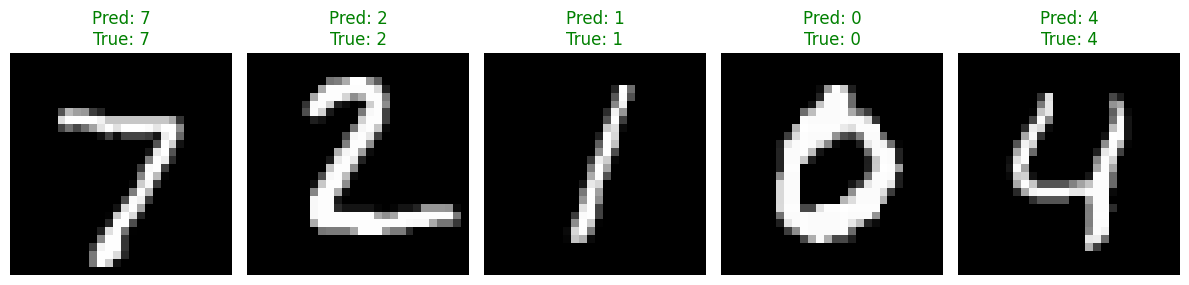

In [12]:
print("\nSample predictions:")
show_sample_predictions()

In [13]:
def predict_digit(image_index):
    """Predict a single digit"""
    image = test_images[image_index]
    prediction = model.predict(np.expand_dims(image, axis=0), verbose=0)
    predicted_digit = np.argmax(prediction)

    plt.figure(figsize=(4, 4))
    plt.imshow(image, cmap='gray')
    plt.title(f"Predicted: {predicted_digit}\nActual: {test_labels[image_index]}")
    plt.axis('off')
    plt.show()

    print(f"Probabilities for each digit (0-9):")
    for i, prob in enumerate(prediction[0]):
        print(f"  {i}: {prob:.4f}")

    return predicted_digit


Testing with first test image:


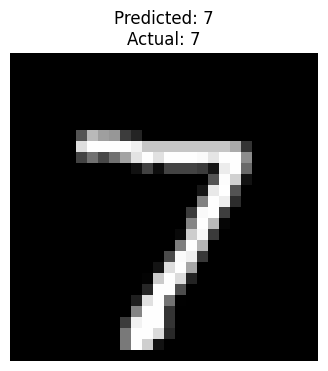

Probabilities for each digit (0-9):
  0: 0.0000
  1: 0.0000
  2: 0.0000
  3: 0.0001
  4: 0.0000
  5: 0.0000
  6: 0.0000
  7: 0.9999
  8: 0.0000
  9: 0.0000


np.int64(7)

In [14]:
print("\nTesting with first test image:")
predict_digit(0)